<a href="https://colab.research.google.com/github/SLucy0/Data_Analytics/blob/main/Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cloning Github repository in Colab.

In [45]:
!git clone https://github.com/SLucy0/SI-Ferry-Ridership.git

fatal: destination path 'SI-Ferry-Ridership' already exists and is not an empty directory.


Check number of actual files.

In [46]:
import os

base_path = "/content/SI-Ferry-Ridership"
files = os.listdir(base_path)

len(files)

109

Count real data files. There should be 108 files.

In [47]:
data_files = []

for root, dirs, files in os.walk("/content/SI-Ferry-Ridership"):
    for f in files:
        if f.endswith((".xlsx", ".xls", ".csv")):
            data_files.append(os.path.join(root, f))

len(data_files)

108

Setting path. Reading files directly from Github.

In [48]:
import os
import pandas as pd

base_path = "/content/SI-Ferry-Ridership"
files = sorted(os.listdir(base_path))

Before using Github, Mounting Google Drive-

Connect to Google Drive and find the files.
Looks inside my Drive to confirm access.
Sets a folder path (capstone_project) where my data files live.
Gets a sorted list of all files in that folder (default, ascending order).

In [49]:
# Data source: NYC Open Data, Staten Island Ferry Ridership Counts
# url = "https://nycdot.sharepoint.com/sites/publicshare/OpenData/Forms/AllItems.aspx?id=%2Fsites%2Fpublicshare%2FOpenData%2FStaten%20Island%20Ferry%20Passenger%20Counts%20-%20by%20Month"
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)
#Confirming access
#import os
#os.listdir('/content/drive/MyDrive')

Bring in Panda analysis library.

In [50]:
import pandas as pd

Before using Github. Setting base path.

In [51]:
#base_path = "/content/drive/MyDrive/capstone_project"

Loading files-
Create an empty list (dfs) to store data from each file.
List files in Directory.

In [52]:
files = sorted(os.listdir(base_path))

Discovered that a select group of files were structured in ways that I could not identify. Used the output after running and rerunning 108 files to arrive at the list of files listed below.

In [53]:
dfs = []

#The internal structure of SIFMonthlyRidership_2019_12.xlsx
  #might have metadata, empty rows, or a very specific header format that the
  #general approach isn't capturing. SIFMonthlyRidership_2019_12.xlsx is being skipped for now,
  #preventing the data in that file from corrupting the rest of the combined data.
file_header_map = {
    'SIFMonthlyRidership_2019_12.xlsx': 0,
    'SIFMonthlyRidership_2020_02 .xlsx': 2,
    'SIFMonthlyRidership_2020_03 .xlsx': 2,
    'SIFMonthlyRidership_2020_04.xlsx': 2,
    'SIFMonthlyRidership_2020_05.xlsx': 3,
    'SIFMonthlyRidership_2020_06.xlsx': 3,
    'SIFMonthlyRidership_2020_07.xlsx': 3,
    'SIFMonthlyRidership_2020_09.xlsx': 2,
    'SIFMonthlyRidership_2020_10.xlsx': 2,
    'SIFMonthlyRidership_2020_11.xlsx': 2,
    'SIFMonthlyRidership_2020_12.xlsx': 3
}

Clean the data and normalize the data.
Loop 1: Read each file. Default header is 0-indexed. Line 5 is index 4.

Defined a special map (file_header_map) for files that have weird formatting.

Loop 2: Check worksheet names. Open each file differently depending on whether it’s a CSV or an Excel file.  In Excel files, look at all available sheet names. Find the right sheet (‘TOTALS’ or ‘TOTAL’).

In [54]:
# Open the files
for file in files:
    df = None
    file_path = f"{base_path}/{file}"

    # Default header row (Excel row 5 → index 4)
    current_header_row_index = 4

    # Override header row if file is in the map
    if file in file_header_map:
        current_header_row_index = file_header_map[file]

    # Load file
    if file.endswith('.csv'):
        df = pd.read_csv(file_path, header=current_header_row_index)

    elif file.endswith(('.xls', '.xlsx')):
        try:
            # Try exact "TOTALS"
            df = pd.read_excel(file_path, sheet_name='TOTALS', header=current_header_row_index)

      # If that fails, look at all available sheet names
        except ValueError:
            try:
                xls = pd.ExcelFile(file_path)
                available_sheets = xls.sheet_names

                found_sheet_name = None

                # Look for "TOTALS" (case-insensitive)
                for sheet in available_sheets:
                    if sheet.strip().upper() == 'TOTALS':
                        found_sheet_name = sheet
                        break

                # If not found, look for "TOTAL"
                if found_sheet_name is None:
                    for sheet in available_sheets:
                        if sheet.strip().upper() == 'TOTAL':
                            found_sheet_name = sheet
                            break

                # If found, load data
                if found_sheet_name:
                    df = pd.read_excel(file_path, sheet_name=found_sheet_name, header=current_header_row_index)
                # Skip this file and move on to the next one
                # print a message explaining why file is skipped and list the sheets it does have
                else:
                    print(f"Skipping {file} (no 'TOTALS' or 'TOTAL' sheet found). Available sheets: {available_sheets}")
                    continue

            except Exception as e:
                print(f"Error checking sheets for {file}: {e}")
                print(f"Skipping {file} due to sheet error.")
                continue

        except Exception as e:
            print(f"Error reading Excel file {file}: {e}")
            continue

    # Using Panda, create new column and fill it with the value stored in old file
    if df is not None:
        df['source_file'] = file

        # Normalize column names
        df.columns = [str(col).strip().upper() for col in df.columns]

#Defining the columns to keep
        column_rename_map = {
            'DAY': 'Day',
            'DATE': 'Date',
            'WHT': 'WHT',
            'STG': 'STG',
            'COMBINED TOTAL': 'Combined',
            'COMBINED': 'Combined',
            'COMBINED TOTAL.1': 'Combined',
            'DIFFERENCE': 'Difference',
            'DIFF': 'Difference',
            'SOURCE_FILE': 'source_file'
        }
        # Apply the renaming
        df.rename(columns=column_rename_map, inplace=True)

        # Debug check for special files
        if file in file_header_map:
            print(f"DEBUG: Columns for {file}: {df.columns}")

        # Keep only desired columns
        desired_final_cols = ['Day', 'Date', 'WHT', 'STG', 'Combined', 'Difference', 'source_file']
        final_cols_to_select = [col for col in desired_final_cols if col in df.columns]
        df = df[final_cols_to_select].copy()

        # Filter valid days. Keep only valid weekday rows
        valid_days = ['SUN', 'MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT']
        if 'Day' in df.columns:
            df = df[df['Day'].astype(str).str.strip().str.upper().isin(valid_days)]

        # Convert it into a proper date format
        # Ensuring the dataframe has a proper Date column
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
            invalid_count = df['Date'].isna().sum()

            # If something isn’t a valid date, replace it with “missing” (NaT)
            # Count invalid conversions
            # If there’s no Date column, print a message
            if invalid_count > 0:
                print(f"{file}: {invalid_count} invalid dates")
        else:
            print(f"'Date' column not found in {file}")

        # Convert ridership columns to numeric columns
        # Convert to integer/float
        # If 'data' can't be converted, change to Nan
        numeric_cols = ['WHT', 'STG', 'Combined', 'Difference']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # Save the cleaned file
        dfs.append(df)

# Combine all dataframes/stack all the cleaned files into one table
combined_df = pd.concat(dfs, ignore_index=True)

'Date' column not found in SIFMonthlyRidership_2018_08.xls
DEBUG: Columns for SIFMonthlyRidership_2019_12.xlsx: Index(['UNNAMED: 0', 'DECEMBER 2019 STATEN ISLAND FERRY RIDERSHIP',
       'UNNAMED: 2', 'UNNAMED: 3', 'UNNAMED: 4', 'UNNAMED: 5', 'source_file'],
      dtype='object')
'Date' column not found in SIFMonthlyRidership_2019_12.xlsx
'Date' column not found in SIFMonthlyRidership_2020_02.xlsx
DEBUG: Columns for SIFMonthlyRidership_2020_04.xlsx: Index(['UNNAMED: 0', 'UNNAMED: 1', 'UNNAMED: 2', 'UNNAMED: 3', 'UNNAMED: 4',
       'UNNAMED: 5', 'source_file'],
      dtype='object')
'Date' column not found in SIFMonthlyRidership_2020_04.xlsx
DEBUG: Columns for SIFMonthlyRidership_2020_05.xlsx: Index(['2020-05-01 00:00:00', 'UNNAMED: 1', 'UNNAMED: 2', 'UNNAMED: 3',
       'UNNAMED: 4', 'UNNAMED: 5', 'source_file'],
      dtype='object')
'Date' column not found in SIFMonthlyRidership_2020_05.xlsx
DEBUG: Columns for SIFMonthlyRidership_2020_06.xlsx: Index(['2020-06-20 00:00:00', 'UNNAMED:

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""C

Loading first 10 rows to check for column headers beginning in 2017.

In [55]:
display(combined_df.head())
print(combined_df.columns)

,Day,Date,WHT,STG,Combined,Difference,source_file
0,SUN,2017-01-01,28267.0,20989.0,49256.0,7278.0,SIFMonthlyRidership_2017_01.xls
1,MON,2017-01-02,19276.0,16896.0,36172.0,2380.0,SIFMonthlyRidership_2017_01.xls
2,TUE,2017-01-03,29835.0,27475.0,57310.0,2360.0,SIFMonthlyRidership_2017_01.xls
3,WED,2017-01-04,38315.0,35031.0,73346.0,3284.0,SIFMonthlyRidership_2017_01.xls
4,THU,2017-01-05,33587.0,31073.0,64660.0,2514.0,SIFMonthlyRidership_2017_01.xls


Index(['Day', 'Date', 'WHT', 'STG', 'Combined', 'Difference', 'source_file'], dtype='object')


Loading last 10 rows to check for dates through then end of 2025.

In [56]:
display(combined_df.tail())
print(combined_df.columns)

,Day,Date,WHT,STG,Combined,Difference,source_file
3196,SAT,2025-12-27,18838.0,18621.0,37459.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3197,SUN,2025-12-28,25009.0,24426.0,49435.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3198,MON,2025-12-29,25856.0,25726.0,51582.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3199,TUE,2025-12-30,32577.0,32135.0,64712.0,NaN,SIFMonthlyRidership_2025_12.xlsx
3200,WED,2025-12-31,25970.0,27109.0,53079.0,NaN,SIFMonthlyRidership_2025_12.xlsx


Index(['Day', 'Date', 'WHT', 'STG', 'Combined', 'Difference', 'source_file'], dtype='object')


Plot monthly ridership trends 2017 through 2025.

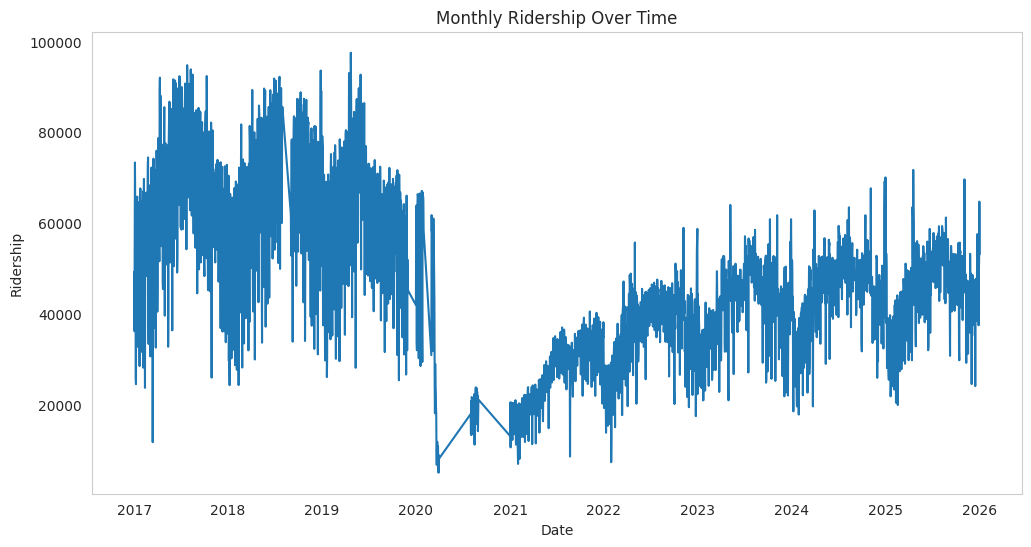

In [57]:
import matplotlib.pyplot as plt

# Ensure sorted by date
combined_df = combined_df.sort_values('Date')

# Aggregate daily totals
daily_ridership = combined_df.groupby('Date')['Combined'].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_ridership)
plt.title('Monthly Ridership Over Time')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.grid()
plt.show()

Calculate the monthly average ridership 2017 through 2025. The rolling average is a good way to see long-term trends.

In [58]:
window_size = 30

rolling_avg = daily_ridership.rolling(window=window_size).mean()

# Convert to DataFrame so we can work with dates
rolling_df = rolling_avg.reset_index()
rolling_df.columns = ['Date', 'rolling_avg']

# Look at rolling_avg column, remove rows with NaN
rolling_df = rolling_df.dropna(subset=['rolling_avg'])

# Add month (year and month to avoid mixing years)
rolling_df['year_month'] = rolling_df['Date'].dt.to_period('M')

# Compute monthly average for monthly_rolling_ave
monthly_rolling_avg = (
    rolling_df.groupby('year_month')['rolling_avg']
    .mean()
    .reset_index(name='avg_rolling_ridership')
)

# Convert to integers
monthly_rolling_avg['avg_rolling_ridership'] = (
    monthly_rolling_avg['avg_rolling_ridership']
    .round(0)
    .astype('Int64')  # handles missing values safely
)

# Make month labels cleaner for display/plotting
monthly_rolling_avg['year_month'] = monthly_rolling_avg['year_month'].astype(str)

# Print results
print(f"Rolling average window size: {window_size}")
print(monthly_rolling_avg)

Rolling average window size: 30
   year_month  avg_rolling_ridership
0     2017-01                  52090
1     2017-02                  53580
2     2017-03                  56768
3     2017-04                  63098
4     2017-05                  68438
..        ...                    ...
92    2025-08                  53676
93    2025-09                  50261
94    2025-10                  47883
95    2025-11                  46376
96    2025-12                  43405

[97 rows x 2 columns]


Plot monthly rolling average ridership between 2017 through 2025.

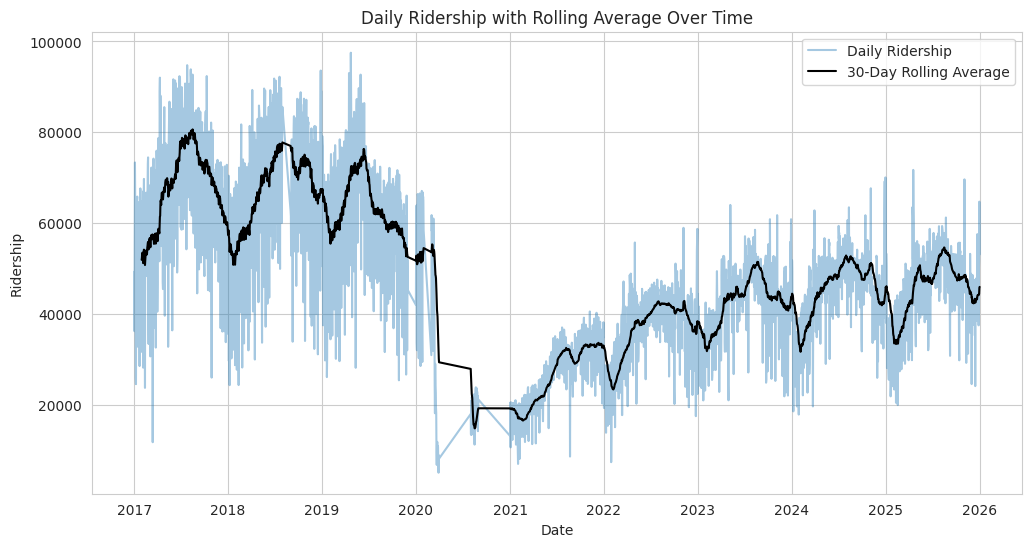

In [59]:
import matplotlib.pyplot as plt

# The daily_ridership and combined_df are already prepared from previous cells.
# window_size is also defined in a previous cell, but re-defining for clarity in this plot cell.
window_size = 30

# Calculate the rolling average
rolling_avg = daily_ridership.rolling(window=window_size).mean()

# Plotting the daily ridership and the rolling average
plt.figure(figsize=(12,6))
plt.plot(daily_ridership, alpha=0.4, label='Daily Ridership')
plt.plot(rolling_avg, color='black', label=f'{window_size}-Day Rolling Average')
plt.title('Daily Ridership with Rolling Average Over Time')
plt.xlabel('Date')
plt.ylabel('Ridership')
plt.legend()
plt.grid(True)
plt.show()

Identify peak travel day of the week, 2017 through 2025.

period      weekday  
Pre-COVID   Monday       68907
            Tuesday      71887
            Wednesday    72972
            Thursday     72955
            Friday       72849
            Saturday     53103
            Sunday       44094
COVID       Monday       33523
            Tuesday      36010
            Wednesday    34948
            Thursday     34764
            Friday       35254
            Saturday     28530
            Sunday       25333
Post-COVID  Monday       47300
            Tuesday      46372
            Wednesday    47109
            Thursday     47214
            Friday       48612
            Saturday     43573
            Sunday       38652
Other       Monday        <NA>
            Tuesday       <NA>
            Wednesday     <NA>
            Thursday      <NA>
            Friday        <NA>
            Saturday      <NA>
            Sunday        <NA>
Name: Combined, dtype: Int64


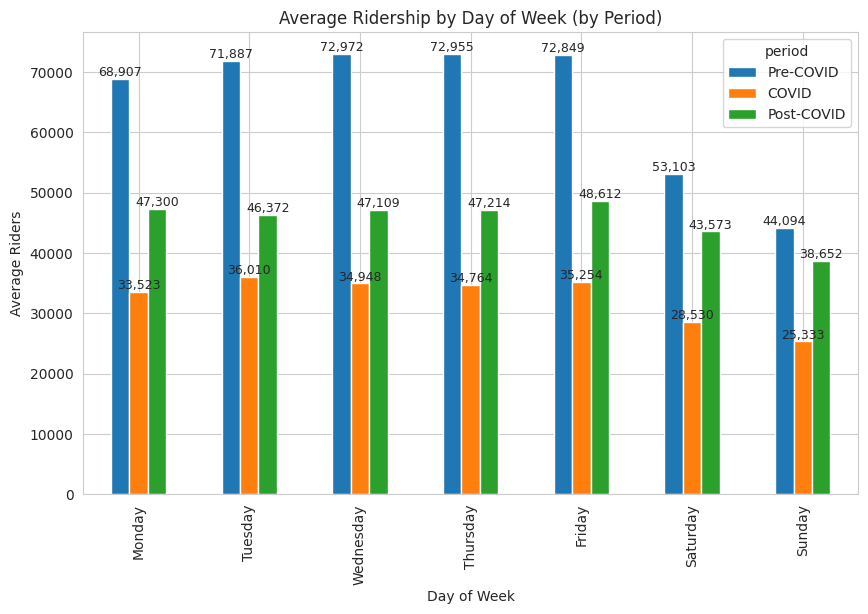

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Create weekday column
combined_df['weekday'] = combined_df['Date'].dt.day_name()

# Define weekday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
combined_df['weekday'] = pd.Categorical(combined_df['weekday'], categories=weekday_order, ordered=True)

# Create time period column
conditions = [
    (combined_df['Date'] >= '2017-01-01') & (combined_df['Date'] <= '2020-02-29'),
    (combined_df['Date'] >= '2020-03-01') & (combined_df['Date'] <= '2023-04-30'),
    (combined_df['Date'] >= '2023-05-01') & (combined_df['Date'] <= '2025-12-31')
]

choices = ['Pre-COVID', 'COVID', 'Post-COVID']

combined_df['period'] = np.select(conditions, choices, default='Other')

# Define order for period
period_plot_order = ['Pre-COVID', 'COVID', 'Post-COVID']
combined_df['period'] = pd.Categorical(
    combined_df['period'],
    categories=period_plot_order + ['Other'],
    ordered=True
)

# Group data
ridership = combined_df.groupby(['period', 'weekday'], observed=False)['Combined'] \
    .mean().round(0).astype('Int64')

ridership_to_plot = ridership.loc[period_plot_order]

print(ridership)

# Plot
ax = ridership_to_plot.unstack(level=0).plot(kind='bar', figsize=(10,6))

plt.title('Average Ridership by Day of Week (by Period)')
plt.ylabel('Average Riders')
plt.xlabel('Day of Week')

# Add data labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()

        if pd.notna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{int(height):,}',  # comma formatting (e.g., 45,000)
                ha='center',
                va='bottom',
                fontsize=9
            )

plt.show()

Calculate the percent change Pre-COVID to COVID and COVID to Post-COVID for each weekday.

           Pre→COVID %  COVID→Post-COVID %
weekday                                   
Monday           -51.4                41.1
Tuesday          -49.9                28.8
Wednesday        -52.1                34.8
Thursday         -52.3                35.8
Friday           -51.6                37.9
Saturday         -46.3                52.7
Sunday           -42.5                52.6


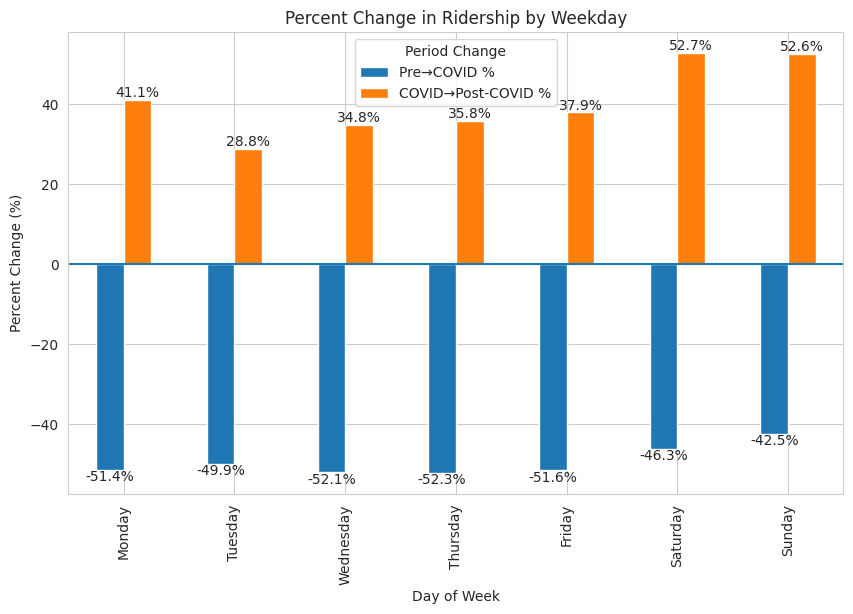

In [61]:
# Create the table
ridership = combined_df.groupby(['weekday', 'period'], observed=False)['Combined'].mean()

ridership_wide = ridership.unstack(level='period')

# Calculate percent changes between Pre-COVID and COVID, and COVID and Post-COVID
ridership_pct = pd.DataFrame(index=ridership_wide.index)

ridership_pct['Pre→COVID %'] = (
    (ridership_wide['COVID'] - ridership_wide['Pre-COVID'])
    / ridership_wide['Pre-COVID'] * 100
)

ridership_pct['COVID→Post-COVID %'] = (
    (ridership_wide['Post-COVID'] - ridership_wide['COVID'])
    / ridership_wide['COVID'] * 100
)

# Round numbers for readability
ridership_pct = ridership_pct.round(1)

print(ridership_pct)

# Place the columns in Pre-COVID and Post-COVID
column_order = ['Pre→COVID %', 'COVID→Post-COVID %']

ridership_pct = ridership_pct[column_order]

# Plot the columns
ax = ridership_pct.plot(kind='bar', figsize=(10,6)) # Assign the plot to 'ax'

plt.title('Percent Change in Ridership by Weekday')
plt.ylabel('Percent Change (%)')
plt.xlabel('Day of Week')
plt.axhline(0)  # baseline for increase/decrease
plt.legend(title='Period Change')

# Add data labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()

        # Skip NaN values
        if pd.notna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{height:.1f}%',
                ha='center',
                va='bottom' if height >= 0 else 'top'
            )

plt.show()

Plot monthly ridership to identify peak travel months. Pre-COVID and Post-COVID periods

/tmp/ipykernel_4917/1695208674.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['month_name'] = pd.Categorical(


period      Pre-COVID  Post-COVID
month_name                       
January         54493       34368
February        58083       36766
March           60672       42164
April           67977       46697
May             71671       47355
June            73916       46421
July            72591       52011
August          69862       51562
September       66818       45770
October         66730       48432
November        62125       43133
December        61447       44992


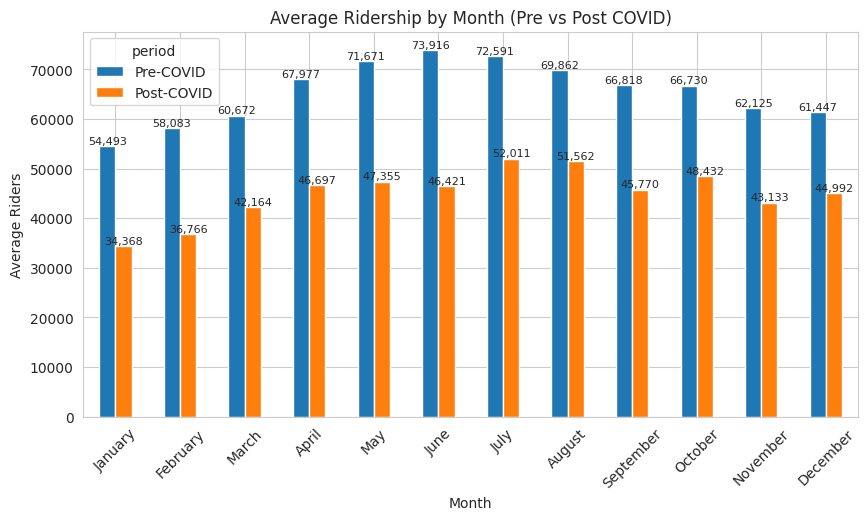

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Create month columns
combined_df['month'] = combined_df['Date'].dt.month
combined_df['month_name'] = combined_df['Date'].dt.month_name()

# Create period column
conditions = [
    (combined_df['Date'] >= '2017-01-01') & (combined_df['Date'] <= '2020-02-29'),
    (combined_df['Date'] >= '2023-05-01') & (combined_df['Date'] <= '2025-12-31')
]

choices = ['Pre-COVID', 'Post-COVID']

combined_df['period'] = np.select(conditions, choices, default='COVID')

# Filter out COVID
filtered_df = combined_df[combined_df['period'].isin(['Pre-COVID', 'Post-COVID'])]

# Month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

filtered_df['month_name'] = pd.Categorical(
    filtered_df['month_name'],
    categories=month_order,
    ordered=True
)

# Group by month and period
monthly_avg = filtered_df.groupby(['month_name', 'period'], observed=False)['Combined'] \
    .mean().round(0)

# Convert to wide format
monthly_avg_wide = monthly_avg.unstack(level='period')

# Set column order
monthly_avg_wide = monthly_avg_wide[['Pre-COVID', 'Post-COVID']]

print(monthly_avg_wide.astype(int))

# Plot
ax = monthly_avg_wide.plot(kind='bar', figsize=(10,5))

plt.title('Average Ridership by Month (Pre vs Post COVID)')
plt.ylabel('Average Riders')
plt.xlabel('Month')
plt.xticks(rotation=45)

# Add data labels
for container in ax.containers:
    for bar in container:
        height = bar.get_height()

        if pd.notna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f'{int(height):,}',
                ha='center',
                va='bottom',
                fontsize=8
            )

plt.show()

Create a function to plot Pre-COVID and Post-COVID ferry ridership. A function will make the workflow cleaner, reusable, and easier to extend. For example, adding more periods.

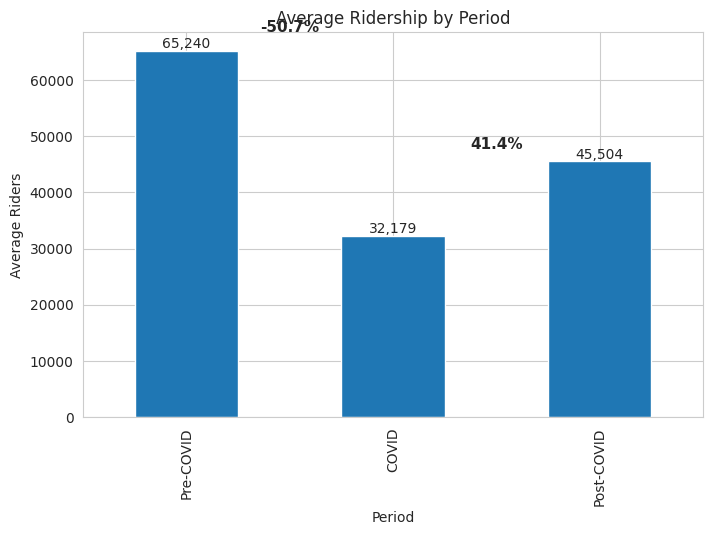

,Combined
period,
Pre-COVID,65239.621047
COVID,32178.598522
Post-COVID,45504.439785


In [63]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Creating a function to generate the plot by
# defining a set of instructions called 'plot_ridership_by_period'
def plot_ridership_by_period(df):

    # Copy dataset so original data is not modified
    df = df.copy()

    # Create columns. Define periods
    conditions = [
        (df['Date'] >= '2017-01-01') & (df['Date'] <= '2020-02-29'),
        (df['Date'] >= '2020-03-01') & (df['Date'] <= '2023-04-30'),
        (df['Date'] >= '2023-05-01') & (df['Date'] <= '2025-12-31')
    ]

    choices = ['Pre-COVID', 'COVID', 'Post-COVID']
    df['period'] = np.select(conditions, choices, default='Other')

    # Keep only defined periods
    period_order = ['Pre-COVID', 'COVID', 'Post-COVID']
    df_filtered = df[df['period'].isin(period_order)].copy()

    # Compute averages
    avg_ridership = df_filtered.groupby('period')['Combined'].mean()
    avg_ridership = avg_ridership.reindex(period_order)

    # Percent changes
    pre, covid, post = avg_ridership

    pct_pre_to_covid = (covid - pre) / pre * 100
    pct_covid_to_post = (post - covid) / covid * 100

    # Plot
    ax = avg_ridership.plot(kind='bar', figsize=(8,5))

    plt.title('Average Ridership by Period')
    plt.ylabel('Average Riders')
    plt.xlabel('Period')

    # Value labels on bars
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f'{height:,.0f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

    # Place percent change labels
    bars = ax.patches

    x_mid_1 = (bars[0].get_x() + bars[1].get_x()) / 2 + bars[0].get_width()/2
    y_mid_1 = max(pre, covid)

    ax.text(
        x_mid_1,
        y_mid_1 * 1.05,
        f'{pct_pre_to_covid:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

    x_mid_2 = (bars[1].get_x() + bars[2].get_x()) / 2 + bars[1].get_width()/2
    y_mid_2 = max(covid, post)

    ax.text(
        x_mid_2,
        y_mid_2 * 1.05,
        f'{pct_covid_to_post:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

    plt.show()

    # Create table
    return avg_ridership

table = plot_ridership_by_period(combined_df)
table

Compare ferry ridership over presidential terms (Obama vs. Trump vs Biden vs Trump again).

In [64]:
# Defining time periods by presidential terms
def label_president(date):
    if pd.to_datetime('2017-01-01') <= date <= pd.to_datetime('2017-01-19'):
        return 'Obama'
    elif pd.to_datetime('2017-01-20') <= date <= pd.to_datetime('2021-01-19'):
        return 'Trump (1st Term)'
    elif pd.to_datetime('2021-01-20') <= date <= pd.to_datetime('2025-01-19'):
        return 'Biden'
    elif pd.to_datetime('2025-01-20') <= date <= pd.to_datetime('2025-12-31'):
        return 'Trump (2nd Term)'
    else:
        return 'Other'

combined_df['president'] = combined_df['Date'].apply(label_president)


Plot average ferry ridership by presidential term.

president
Obama               52318
Trump (1st Term)    62518
Biden               38525
Trump (2nd Term)    46125
Name: Combined, dtype: int64


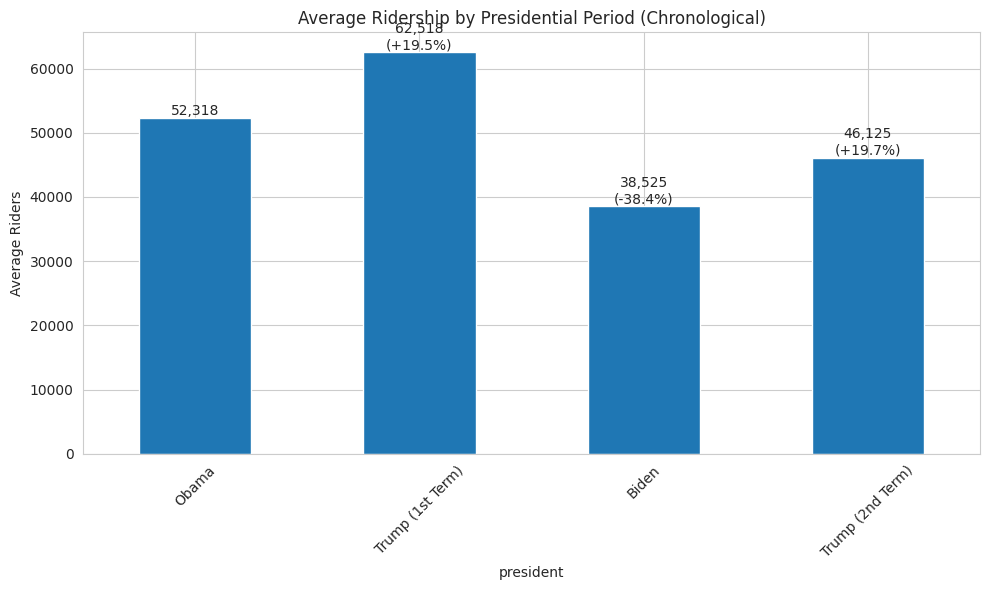

In [65]:
import matplotlib.pyplot as plt

# Group by president and place in chronological order
pres_summary = combined_df.groupby('president')['Combined'].mean()

chronological_order = ['Obama', 'Trump (1st Term)', 'Biden', 'Trump (2nd Term)']
pres_summary_ordered = pres_summary.reindex(chronological_order)

# Print values
print(pres_summary_ordered.round(0).astype(int))

# Compute percent change between presidential periods
pct_change = pres_summary_ordered.pct_change() * 100

# Plot
ax = pres_summary_ordered.plot(kind='bar', figsize=(10,6))

plt.title('Average Ridership by Presidential Period (Chronological)')
plt.ylabel('Average Riders')
plt.xticks(rotation=45)

# Add value labels and percent change labels
for i, (value, pct) in enumerate(zip(pres_summary_ordered, pct_change)):
    # Skip first period for percen change (NaN)
    if i == 0:
        label = f"{value:,.0f}"
    else:
        label = f"{value:,.0f}\n({pct:+.1f}%)"

    ax.text(
        i,
        value,
        label,
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

Plot average ferry ridership by presidential term using function, Seaborn and Matplotlib.

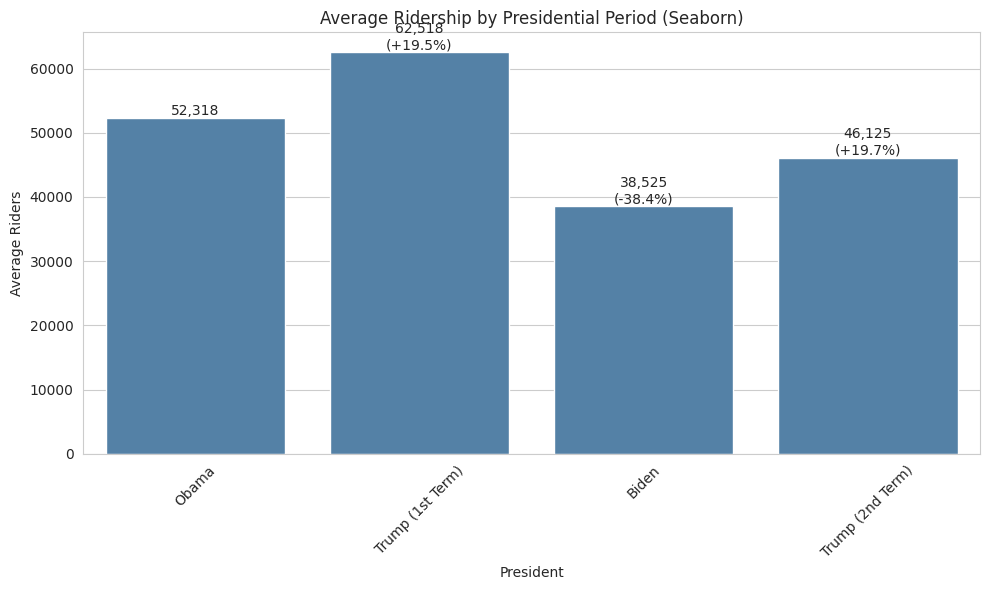

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group and order
pres_summary = combined_df.groupby('president')['Combined'].mean()

chronological_order = ['Obama', 'Trump (1st Term)', 'Biden', 'Trump (2nd Term)']
pres_summary_ordered = pres_summary.reindex(chronological_order)

# Percent change
pct_change = pres_summary_ordered.pct_change() * 100

# Create DataFrame for seaborn (recommended approach)
plot_df = pd.DataFrame({
    'President': pres_summary_ordered.index,
    'Ridership': pres_summary_ordered.values,
    'PctChange': pct_change.values
})

# Set style
sns.set_style("whitegrid")

# Create figure
plt.figure(figsize=(10,6))

# Seaborn bar plot
ax = sns.barplot(
    data=plot_df,
    x='President',
    y='Ridership',
    color='steelblue'
)

# Add labels on top of bars
for i, row in plot_df.iterrows():
    value = row['Ridership']
    pct = row['PctChange']

    if pd.isna(pct):
        label = f"{value:,.0f}"
    else:
        label = f"{value:,.0f}\n({pct:+.1f}%)"

    ax.text(
        i,
        value,
        label,
        ha='center',
        va='bottom',
        fontsize=10
    )

# Titles and formatting
plt.title('Average Ridership by Presidential Period (Seaborn)')
plt.ylabel('Average Riders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()